In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

In [38]:
df = pd.read_csv('weatherAUS.csv')
print(df.shape)
df.head(3)

(145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No


In [39]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [40]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'percent': missing_pct})
print(missing_df[missing_df['count'] > 0].head(10))

               count  percent
Sunshine       69835    48.01
Evaporation    62790    43.17
Cloud3pm       59358    40.81
Cloud9am       55888    38.42
Pressure9am    15065    10.36
Pressure3pm    15028    10.33
WindDir9am     10566     7.26
WindGustDir    10326     7.10
WindGustSpeed  10263     7.06
Humidity3pm     4507     3.10


In [41]:
rain_counts = df['RainTomorrow'].value_counts()
print(rain_counts)

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64


<Axes: >

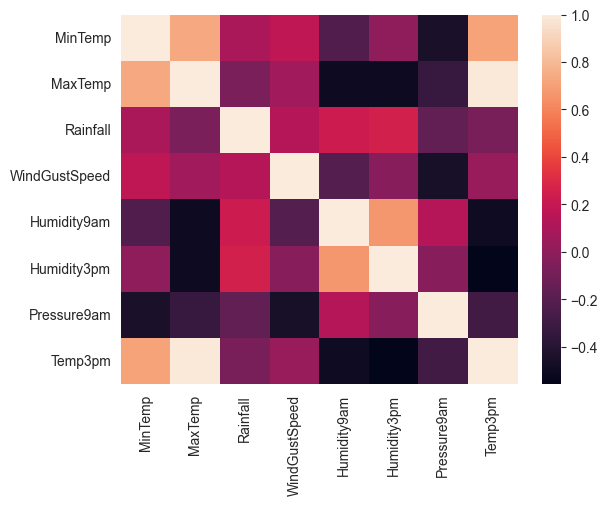

In [42]:
num_cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
            'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Temp3pm']
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix)

In [43]:
# Видаляємо рядки де немає таргету — з ними нічого не зробиш
df = df.dropna(subset=['RainTomorrow'])

In [44]:
# Прибираємо колонку Date — вже витягли Month, рік не буду брати бо
# не хочу щоб модель просто "запам'ятала" тренд по рокам
df = df.drop(columns=['Date'])

In [45]:
# Визначаємо категоріальні і числові колонки
cat_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Month']
num_cols = [col for col in df.columns if col not in cat_cols + ['RainTomorrow']]

In [46]:
# Перетворюємо Month в категоріальну (він вже числовий, але логічно — категорія)
df['Month'] = df['Month'].astype(str)

KeyError: 'Month'

In [35]:
# Заповнення пропусків
# Для числових — медіана (стійка до викидів, краще за середнє)
# Для категоріальних — найчастіше значення (мода)

num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

KeyError: "['Month'] not in index"

In [15]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))


NameError: name 'cat_cols' is not defined